Loading OOD Data for Task 1: Relevance...
Testing 10846 samples...


Inference Progress: 100%|██████████| 339/339 [06:03<00:00,  1.07s/it]



=== Task 1: Relevance OOD Report ===
                 precision    recall  f1-score   support

not_informative       0.51      0.50      0.50      5561
    informative       0.48      0.49      0.49      5285

       accuracy                           0.50     10846
      macro avg       0.50      0.50      0.50     10846
   weighted avg       0.50      0.50      0.50     10846

Saved confusion matrix as 'ood_cm_relevance.png'


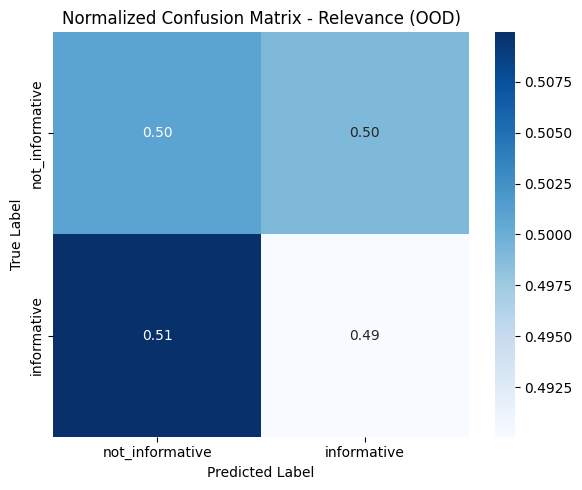

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import CLIPProcessor
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import ast
from tqdm import tqdm  # <-- Added for the progress bar

# --- CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
DATASET_PATH = "MEDIC_test_OOD_only.tsv"
IMAGE_BASE_DIR = r"F:\research\chatbot\MEDIC"

# Target Classes for Task 1
target_classes = ["not_informative", "informative"]

# --- DATASET HANDLING ---
class RelevanceDataset(Dataset):
    def __init__(self, tsv_path, image_dir):
        self.df = pd.read_csv(tsv_path, sep='\t')
        self.image_dir = image_dir
        
        # Clean the MEDIC informative column
        self.df['label_clean'] = self.df['informative'].apply(self._clean_label)
        self.df = self.df.dropna(subset=['label_clean', 'image_path'])
        
        # Keep only valid classes
        self.df = self.df[self.df['label_clean'].isin(target_classes)].reset_index(drop=True)
        
        self.label_to_idx = {label: idx for idx, label in enumerate(target_classes)}
        
        # <-- FIX 1: Explicitly force the fast Rust-based processor
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=True)

    def _clean_label(self, label):
        try:
            if str(label).startswith('['):
                label_list = ast.literal_eval(label)
                return label_list[0] if len(label_list) > 0 else "unknown"
            return str(label)
        except:
            return str(label)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, str(row['image_path']))
        text = str(row.get('tweet_text', '')) 
        
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = self.processor(text=[text], images=image, return_tensors="pt", padding=True, truncation=True)
            return inputs['pixel_values'].squeeze(0), inputs['input_ids'].squeeze(0), inputs['attention_mask'].squeeze(0), torch.tensor(self.label_to_idx[row['label_clean']])
        except:
            return None

def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0: return None, None, None, None
    img, txt, mask, lbl = zip(*batch)
    return torch.stack(img), torch.nn.utils.rnn.pad_sequence(txt, batch_first=True), torch.nn.utils.rnn.pad_sequence(mask, batch_first=True), torch.stack(lbl)

# --- MODEL PLACEHOLDER ---
class CrisisCLIPModel(nn.Module):
    def __init__(self):
        super().__init__()
        pass
    def forward(self, pixel_values, input_ids, attention_mask):
        # DUMMY RETURN: Replace with your actual model forward pass
        return torch.randn(pixel_values.shape[0], len(target_classes)).to(pixel_values.device)

# --- EVALUATION ---
print("Loading OOD Data for Task 1: Relevance...")
dataset = RelevanceDataset(DATASET_PATH, IMAGE_BASE_DIR)

# <-- FIX 2: Optimized DataLoader (num_workers=0 avoids Windows multiprocessing hangs, pin_memory speeds up GPU transfer)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)

model = CrisisCLIPModel().to(device)
# model.load_state_dict(torch.load("your_model_weights_task1.pth"))
model.eval()

all_preds, all_labels = [], []

print(f"Testing {len(dataset)} samples...")

# <-- FIX 3: Added tqdm progress bar so you aren't guessing if it's frozen
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference Progress"):
        if batch[0] is None: continue
        pixel_values, input_ids, attention_mask, labels = [b.to(device, non_blocking=True) for b in batch]
        logits = model(pixel_values, input_ids, attention_mask)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- OUTPUT & VISUALIZATION ---
print("\n=== Task 1: Relevance OOD Report ===")
print(classification_report(all_labels, all_preds, target_names=target_classes, zero_division=0))

# Generate Normalized Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_classes, yticklabels=target_classes)
plt.title("Normalized Confusion Matrix - Relevance (OOD)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("ood_cm_relevance.png", dpi=300)
print("Saved confusion matrix as 'ood_cm_relevance.png'")

Loading OOD Data for Task 1: Relevance...
Testing 10846 samples with trained model...


Inference Progress: 100%|██████████| 339/339 [04:55<00:00,  1.15it/s]



=== Task 1: Relevance OOD Report ===
                 precision    recall  f1-score   support

not_informative       0.87      0.89      0.88      5561
    informative       0.88      0.86      0.87      5285

       accuracy                           0.87     10846
      macro avg       0.87      0.87      0.87     10846
   weighted avg       0.87      0.87      0.87     10846

Saved confusion matrix as 'ood_cm_relevance.png'


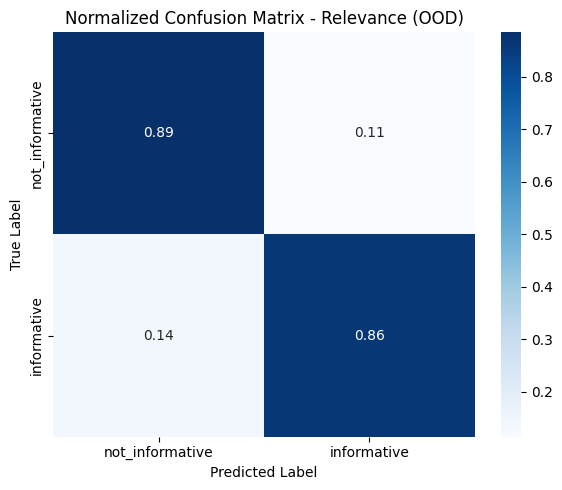

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import ast
from tqdm import tqdm

# --- CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
DATASET_PATH = "MEDIC_test_OOD_only.tsv"
IMAGE_BASE_DIR = r"F:\research\chatbot\MEDIC"

# Target Classes for Task 1
target_classes = ["not_informative", "informative"]

# --- DATASET HANDLING ---
class RelevanceDataset(Dataset):
    def __init__(self, tsv_path, image_dir):
        self.df = pd.read_csv(tsv_path, sep='\t')
        self.image_dir = image_dir
        
        self.df['label_clean'] = self.df['informative'].apply(self._clean_label)
        self.df = self.df.dropna(subset=['label_clean', 'image_path'])
        self.df = self.df[self.df['label_clean'].isin(target_classes)].reset_index(drop=True)
        self.label_to_idx = {label: idx for idx, label in enumerate(target_classes)}
        
        # Fast processor enabled
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=True)

    def _clean_label(self, label):
        try:
            if str(label).startswith('['):
                label_list = ast.literal_eval(label)
                return label_list[0] if len(label_list) > 0 else "unknown"
            return str(label)
        except:
            return str(label)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, str(row['image_path']))
        text = str(row.get('tweet_text', '')) 
        
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = self.processor(text=[text], images=image, return_tensors="pt", padding=True, truncation=True)
            return inputs['pixel_values'].squeeze(0), inputs['input_ids'].squeeze(0), inputs['attention_mask'].squeeze(0), torch.tensor(self.label_to_idx[row['label_clean']])
        except:
            return None

def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0: return None, None, None, None
    img, txt, mask, lbl = zip(*batch)
    return torch.stack(img), torch.nn.utils.rnn.pad_sequence(txt, batch_first=True), torch.nn.utils.rnn.pad_sequence(mask, batch_first=True), torch.stack(lbl)

# --- REBUILT ARCHITECTURE TO MATCH YOUR SAVED WEIGHTS ---
class CrisisCLIPModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # 1. Unified Encoder Backbone (SafeTensors bypass applied here)
        self.clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True)
        
        # 2. Classifier Head tailored EXACTLY to your blueprint
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),       # classifier.0
            nn.BatchNorm1d(512),        # classifier.1
            nn.ReLU(),                  # classifier.2 (Activation)
            nn.Dropout(0.3),            # classifier.3 (Dropout)
            nn.Linear(512, 128),        # classifier.4
            nn.ReLU(),                  # classifier.5 (Activation)
            nn.Linear(128, num_classes) # classifier.6
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        # Extract features
        outputs = self.clip(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        
        # Simple Concatenation (Baseline approach)
        combined_features = torch.cat([outputs.image_embeds, outputs.text_embeds], dim=1)
        
        # Classification
        logits = self.classifier(combined_features)
        return logits

# --- EVALUATION ---
print("Loading OOD Data for Task 1: Relevance...")
dataset = RelevanceDataset(DATASET_PATH, IMAGE_BASE_DIR)

# Optimized DataLoader
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)

model = CrisisCLIPModel(num_classes=2).to(device)

# Load your exact weights (with the PyTorch 2.6 security bypass)
model.load_state_dict(torch.load(r"F:\research\chatbot\MEDIC\best_vlm_model.pth", weights_only=False)) 

model.eval()

all_preds, all_labels = [], []

print(f"Testing {len(dataset)} samples with trained model...")
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference Progress"):
        if batch[0] is None: continue
        pixel_values, input_ids, attention_mask, labels = [b.to(device, non_blocking=True) for b in batch]
        logits = model(pixel_values, input_ids, attention_mask)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- OUTPUT & VISUALIZATION ---
print("\n=== Task 1: Relevance OOD Report ===")
print(classification_report(all_labels, all_preds, target_names=target_classes, zero_division=0))

# Generate Normalized Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_classes, yticklabels=target_classes)
plt.title("Normalized Confusion Matrix - Relevance (OOD)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("ood_cm_relevance.png", dpi=300)
print("Saved confusion matrix as 'ood_cm_relevance.png'")

In [6]:
import torch

checkpoint_path = r"F:\research\chatbot\MEDIC\best_vlm_model.pth"
checkpoint = torch.load(checkpoint_path, weights_only=False)

print("--- Exact Blueprint of Your Saved Model ---")
for key, value in checkpoint.items():
    if "clip" not in key: # Skipping the massive CLIP backbone printout
        print(f"{key}: {value.shape}")

--- Exact Blueprint of Your Saved Model ---
classifier.0.weight: torch.Size([512, 1024])
classifier.0.bias: torch.Size([512])
classifier.1.weight: torch.Size([512])
classifier.1.bias: torch.Size([512])
classifier.1.running_mean: torch.Size([512])
classifier.1.running_var: torch.Size([512])
classifier.1.num_batches_tracked: torch.Size([])
classifier.4.weight: torch.Size([128, 512])
classifier.4.bias: torch.Size([128])
classifier.6.weight: torch.Size([2, 128])
classifier.6.bias: torch.Size([2])


In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
import ast
from tqdm import tqdm

# --- CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
DATASET_PATH = "MEDIC_test_OOD_only.tsv"
IMAGE_BASE_DIR = r"F:\research\chatbot\MEDIC"

target_classes = ["not_informative", "informative"]

# --- DATASET HANDLING ---
class RelevanceDataset(Dataset):
    def __init__(self, tsv_path, image_dir):
        self.df = pd.read_csv(tsv_path, sep='\t')
        self.image_dir = image_dir
        
        self.df['label_clean'] = self.df['informative'].apply(self._clean_label)
        self.df = self.df.dropna(subset=['label_clean', 'image_path'])
        self.df = self.df[self.df['label_clean'].isin(target_classes)].reset_index(drop=True)
        self.label_to_idx = {label: idx for idx, label in enumerate(target_classes)}
        
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=True)

    def _clean_label(self, label):
        try:
            if str(label).startswith('['):
                label_list = ast.literal_eval(label)
                return label_list[0] if len(label_list) > 0 else "unknown"
            return str(label)
        except:
            return str(label)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, str(row['image_path']))
        text = str(row.get('tweet_text', '')) 
        
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = self.processor(text=[text], images=image, return_tensors="pt", padding=True, truncation=True)
            return inputs['pixel_values'].squeeze(0), inputs['input_ids'].squeeze(0), inputs['attention_mask'].squeeze(0), torch.tensor(self.label_to_idx[row['label_clean']])
        except:
            return None

def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0: return None, None, None, None
    img, txt, mask, lbl = zip(*batch)
    return torch.stack(img), torch.nn.utils.rnn.pad_sequence(txt, batch_first=True), torch.nn.utils.rnn.pad_sequence(mask, batch_first=True), torch.stack(lbl)

# --- REBUILT ARCHITECTURE ---
class CrisisCLIPModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True)
        
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        outputs = self.clip(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        combined_features = torch.cat([outputs.image_embeds, outputs.text_embeds], dim=1)
        logits = self.classifier(combined_features)
        
        # Returning features as well so we can plot the t-SNE graph
        return logits, combined_features

# --- EVALUATION ---
print("Loading OOD Data for Task 1: Relevance...")
dataset = RelevanceDataset(DATASET_PATH, IMAGE_BASE_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)

model = CrisisCLIPModel(num_classes=2).to(device)
model.load_state_dict(torch.load(r"F:\research\chatbot\MEDIC\best_vlm_model.pth", weights_only=False)) 
model.eval()

all_preds = []
all_labels = []
all_probs = []      # Needed for ROC Curve
all_features = []   # Needed for t-SNE

print(f"Testing {len(dataset)} samples with trained model...")
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference Progress"):
        if batch[0] is None: continue
        pixel_values, input_ids, attention_mask, labels = [b.to(device, non_blocking=True) for b in batch]
        
        logits, features = model(pixel_values, input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy()) # Probability of the 'informative' class
        all_features.extend(features.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_features = np.array(all_features)

# ==========================================
# GRAPH 1: TEXT REPORT & CONFUSION MATRIX
# ==========================================
print("\n=== Task 1: Relevance OOD Report ===")
print(classification_report(all_labels, all_preds, target_names=target_classes, zero_division=0))

cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_classes, yticklabels=target_classes)
plt.title("Normalized Confusion Matrix - Relevance (OOD)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("ood_cm_relevance.png", dpi=300)
plt.close()
print("Saved 1/3: ood_cm_relevance.png")

# ==========================================
# GRAPH 2: ROC CURVE
# ==========================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (OOD)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ood_roc_relevance.png", dpi=300)
plt.close()
print("Saved 2/3: ood_roc_relevance.png")

# ==========================================
# GRAPH 3: t-SNE LATENT SPACE VISUALIZATION
# ==========================================
print("Calculating t-SNE (This usually takes 1-2 minutes)...")
# We sample 1500 points to keep the t-SNE plot legible and fast to compute
sample_indices = np.random.choice(len(all_features), min(1500, len(all_features)), replace=False)
features_sampled = all_features[sample_indices]
labels_sampled = all_labels[sample_indices]

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(features_sampled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=tsne_results[:, 0], 
    y=tsne_results[:, 1],
    hue=[target_classes[label] for label in labels_sampled],
    palette=sns.color_palette("hsv", 2),
    alpha=0.7,
    s=30
)
plt.title("t-SNE Latent Space - Relevance (OOD)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("ood_tsne_relevance.png", dpi=300)
plt.close()
print("Saved 3/3: ood_tsne_relevance.png")
print("All tasks completed successfully!")

Loading OOD Data for Task 1: Relevance...
Testing 10846 samples with trained model...


Inference Progress: 100%|██████████| 339/339 [08:19<00:00,  1.47s/it]



=== Task 1: Relevance OOD Report ===
                 precision    recall  f1-score   support

not_informative       0.87      0.89      0.88      5561
    informative       0.88      0.86      0.87      5285

       accuracy                           0.87     10846
      macro avg       0.87      0.87      0.87     10846
   weighted avg       0.87      0.87      0.87     10846

Saved 1/3: ood_cm_relevance.png
Saved 2/3: ood_roc_relevance.png
Calculating t-SNE (This usually takes 1-2 minutes)...
Saved 3/3: ood_tsne_relevance.png
All tasks completed successfully!
